In [160]:
from dataclasses import dataclass
import stim
import math
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
    shape: int #[4-square, 6-hex, etc]
    
class ColorCodeCircuit488Test:
    
    def __init__(self, distance, rounds, noise=None):
        #super().__init__(distance, rounds)
        self.qubits = set()
        self.ancilla = set()
        self._tiles = self._generate_layout(distance)
        self.circuit = self._build_circuit(noise)
        
        

    def get_circuit(self):
        return self.circuit
    
    def draw_layout(self):
        if self._tiles is None:
            return
        draw_tiles(self._tiles)

    def _generate_layout(self, distance:int):
        # Implementation for 4.8.8 layout generation
        if (distance-1)%4==0:
            layout = 1
        else:
            layout = 0
        tiles = []
        
        basenum = distance//2
        side = math.ceil(basenum/2)
        rightmost = 0
        #add the base green
        curr = [5,0]
        for _ in range(basenum):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-3,0),(-1,2),(1,2),(3,0)]],
                tuple(curr),
                'green',
                8
            )
            tiles.append(tile)
            rightmost = curr[0]+3
            curr[0] += 8
        
        curr = [2,2]
        for _ in range(side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-2,-2),(0,-2),(2,0),(2,2)]],
                tuple(curr),
                'blue',
                8
            )
            tiles.append(tile)
            #left down
            coord = [curr[0]-1, curr[1]-3]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #right down
            coord = [curr[0]+3, curr[1]+1]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] += 8
            curr[1] += 8
        
        curr = [rightmost-4, 6]
        for _ in range(basenum-side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(2,-2),(0,-2),(-2,0),(-2,2)]],
                tuple(curr),
                'green',
                8
            )
            tiles.append(tile)
            #right down
            coord = [curr[0]+1, curr[1]-3]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #left down
            coord = [curr[0]-3, curr[1]+1]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] -= 8
            curr[1] += 8
        
        if layout==1:
            n = (rightmost+1)//2
            for i in range(len(tiles)):
                tiles[i].qubits = [((2*n)-x,y) for x,y in tiles[i].qubits]
                tiles[i].ancilla = (2*n - tiles[i].ancilla[0], tiles[i].ancilla[1])
                if tiles[i].color == 'green':
                    tiles[i].color = 'blue'
                elif tiles[i].color == 'blue':
                    tiles[i].color = 'green'

        return tiles
        
        

    def _build_circuit(self, noise=None):
        # Implementation for building the circuit
        pass

In [167]:
cc = ColorCodeCircuit488Test(3,2)
tileslayout = cc._generate_layout(7)

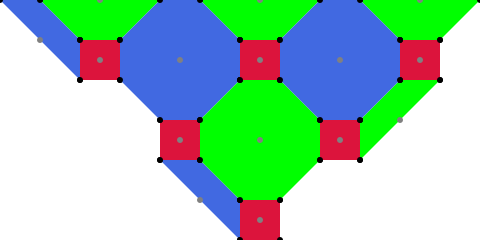

In [168]:
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }

#CC = ColorCodeCircuit666(3,2)
#layout = CC._generate_layout(9)
def draw_tiles(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20, height*20))

    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

draw_tiles(tileslayout)

In [106]:
import os
import sys

print(os.getcwd())
# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
os.chdir('..')

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code\preparation
